<a href="https://colab.research.google.com/github/Vanitha-Jain/capstone/blob/Feature-selection/AtomPairCount2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

filename = '/content/AtomPairs2DCount.csv'  # Corrected filename

if os.path.exists(filename):
    data = pd.read_csv(filename)
    print("File loaded successfully!")  # Optional confirmation message
    print(data)
else:
    print(f"Error: File '{filename}' not found.")

File loaded successfully!
               Name  APC2D1_C_C  APC2D1_C_N  APC2D1_C_O  APC2D1_C_S  \
0      CHEMBL167155          20           1           3           3   
1      CHEMBL166740          18           1           2           5   
2      CHEMBL165038          19           1           2           3   
3      CHEMBL435857          18           1           2           3   
4      CHEMBL352783          18           1           2           3   
...             ...         ...         ...         ...         ...   
1224  CHEMBL5429863          18           3           0           0   
1225  CHEMBL5436920          20           2           0           0   
1226  CHEMBL5405698          20           2           0           0   
1227  CHEMBL5416562          25           2           0           0   
1228      CHEMBL165          15           0           3           0   

      APC2D1_C_P  APC2D1_C_F  APC2D1_C_Cl  APC2D1_C_Br  APC2D1_C_I  ...  \
0              0           0            0     

In [ ]:
data.dtypes

,0
Name,object
APC2D1_C_C,int64
APC2D1_C_N,int64
APC2D1_C_O,int64
APC2D1_C_S,int64
...,...
APC2D10_B_X,int64
APC2D10_Si_Si,int64
APC2D10_Si_X,int64
APC2D10_X_X,int64


In [ ]:
data['bioactivity_class'].replace('active', 'P', inplace=True)
data['bioactivity_class'].replace('inactive', 'N', inplace=True)
data.rename(columns = {"bioactivity_class": "class"}, inplace = True)
data

<ipython-input-4-d75cbf56e791>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['bioactivity_class'].replace('active', 'P', inplace=True)
<ipython-input-4-d75cbf56e791>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True

,Name,APC2D1_C_C,APC2D1_C_N,APC2D1_C_O,APC2D1_C_S,APC2D1_C_P,APC2D1_C_F,APC2D1_C_Cl,APC2D1_C_Br,APC2D1_C_I,...,APC2D10_I_B,APC2D10_I_Si,APC2D10_I_X,APC2D10_B_B,APC2D10_B_Si,APC2D10_B_X,APC2D10_Si_Si,APC2D10_Si_X,APC2D10_X_X,class
0,CHEMBL167155,20,1,3,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1,CHEMBL166740,18,1,2,5,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
2,CHEMBL165038,19,1,2,3,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,N
3,CHEMBL435857,18,1,2,3,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,N
4,CHEMBL352783,18,1,2,3,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,CHEMBL5429863,18,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1225,CHEMBL5436920,20,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1226,CHEMBL5405698,20,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1227,CHEMBL5416562,25,2,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N


In [ ]:
data.isnull().sum().sum()

0

In [ ]:
data.dropna(inplace =True)
data.isnull().sum().sum()

0

In [ ]:
data1 = data.iloc[:,1:781]
data1
data2 = data.iloc[:,-1]

In [ ]:
data1
data2

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
from sklearn.feature_selection import VarianceThreshold
threshold = VarianceThreshold(threshold=.1)
def variance_threshold_selector(data1, threshold=0.10):
    selector = VarianceThreshold(threshold)
    selector.fit(data1)
    return data[data1.columns[selector.get_support(indices=True)]]
data1_HV = variance_threshold_selector(data1)

In [ ]:
data1_HV = variance_threshold_selector(data1)
data1_HV

,APC2D1_C_C,APC2D1_C_N,APC2D1_C_O,APC2D1_C_S,APC2D1_C_F,APC2D1_C_Cl,APC2D1_C_X,APC2D1_N_N,APC2D1_N_O,APC2D1_N_S,...,APC2D10_C_X,APC2D10_N_N,APC2D10_N_O,APC2D10_N_S,APC2D10_N_F,APC2D10_N_X,APC2D10_O_O,APC2D10_O_S,APC2D10_O_F,APC2D10_O_X
0,20,1,3,3,0,0,0,0,0,1,...,0,0,0,0,0,0,2,1,0,0
1,18,1,2,5,0,0,0,0,0,1,...,0,0,0,0,0,0,4,4,0,0
2,19,1,2,3,0,1,1,0,0,1,...,1,0,0,0,0,0,0,0,0,2
3,18,1,2,3,0,1,1,0,0,1,...,1,0,0,0,0,0,0,0,0,2
4,18,1,2,3,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,18,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1225,20,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1226,20,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1227,25,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data2_HV = pd.merge(data1_HV,data2,left_index=True,right_index=True)
data2_HV

,APC2D1_C_C,APC2D1_C_N,APC2D1_C_O,APC2D1_C_S,APC2D1_C_F,APC2D1_C_Cl,APC2D1_C_X,APC2D1_N_N,APC2D1_N_O,APC2D1_N_S,...,APC2D10_N_N,APC2D10_N_O,APC2D10_N_S,APC2D10_N_F,APC2D10_N_X,APC2D10_O_O,APC2D10_O_S,APC2D10_O_F,APC2D10_O_X,class
0,20,1,3,3,0,0,0,0,0,1,...,0,0,0,0,0,2,1,0,0,N
1,18,1,2,5,0,0,0,0,0,1,...,0,0,0,0,0,4,4,0,0,N
2,19,1,2,3,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,2,N
3,18,1,2,3,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,2,N
4,18,1,2,3,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,18,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1225,20,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1226,20,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1227,25,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N


In [ ]:
## remove features that display high correlation with many othe features
correlated_features_1 = set()
corr_matrix_class = data2_HV.corr(numeric_only=True)


for i in range(len(corr_matrix_class.columns)):
    for j in range(i):
        if abs(corr_matrix_class.iloc[i, j]) > 0.9:
            colname = corr_matrix_class.columns[i]
            correlated_features_1.add(colname)
correlated_features_1


{'APC2D10_C_Br',
 'APC2D10_C_C',
 'APC2D10_C_N',
 'APC2D10_C_O',
 'APC2D10_C_S',
 'APC2D10_N_X',
 'APC2D2_C_C',
 'APC2D2_C_Cl',
 'APC2D2_C_F',
 'APC2D2_C_N',
 'APC2D2_C_O',
 'APC2D2_C_X',
 'APC2D2_F_F',
 'APC2D2_F_X',
 'APC2D2_X_X',
 'APC2D3_C_Br',
 'APC2D3_C_C',
 'APC2D3_C_Cl',
 'APC2D3_C_O',
 'APC2D3_C_P',
 'APC2D3_C_S',
 'APC2D3_C_X',
 'APC2D3_N_X',
 'APC2D3_O_X',
 'APC2D4_C_C',
 'APC2D4_C_Cl',
 'APC2D4_C_N',
 'APC2D4_C_O',
 'APC2D4_O_P',
 'APC2D4_S_X',
 'APC2D5_C_C',
 'APC2D5_C_N',
 'APC2D5_C_O',
 'APC2D5_O_X',
 'APC2D6_C_Br',
 'APC2D6_C_C',
 'APC2D6_C_Cl',
 'APC2D6_C_N',
 'APC2D6_C_O',
 'APC2D7_C_Br',
 'APC2D7_C_C',
 'APC2D7_C_N',
 'APC2D7_C_O',
 'APC2D7_O_X',
 'APC2D8_C_C',
 'APC2D8_C_N',
 'APC2D8_C_O',
 'APC2D8_C_X',
 'APC2D8_O_O',
 'APC2D9_C_C',
 'APC2D9_C_N',
 'APC2D9_C_O'}

In [ ]:
def remove_correlated_features(features, data):
    for x in features:
        data.drop(x, axis=1, inplace=True)
    return data

In [ ]:
data3= remove_correlated_features(correlated_features_1, data2_HV)
data3

,APC2D1_C_C,APC2D1_C_N,APC2D1_C_O,APC2D1_C_S,APC2D1_C_F,APC2D1_C_Cl,APC2D1_C_X,APC2D1_N_N,APC2D1_N_O,APC2D1_N_S,...,APC2D10_C_X,APC2D10_N_N,APC2D10_N_O,APC2D10_N_S,APC2D10_N_F,APC2D10_O_O,APC2D10_O_S,APC2D10_O_F,APC2D10_O_X,class
0,20,1,3,3,0,0,0,0,0,1,...,0,0,0,0,0,2,1,0,0,N
1,18,1,2,5,0,0,0,0,0,1,...,0,0,0,0,0,4,4,0,0,N
2,19,1,2,3,0,1,1,0,0,1,...,1,0,0,0,0,0,0,0,2,N
3,18,1,2,3,0,1,1,0,0,1,...,1,0,0,0,0,0,0,0,2,N
4,18,1,2,3,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,18,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1225,20,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1226,20,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1227,25,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N


In [ ]:
data3.to_csv('APC2D.csv')

In [ ]:
X = data3.iloc[:,1:119]  #independent columns
X
y = data3.iloc[:,-1]
y   #target column i.e price range

,class
0,N
1,N
2,N
3,N
4,N
...,...
1224,N
1225,N
1226,N
1227,N


In [ ]:
X

,APC2D1_C_N,APC2D1_C_O,APC2D1_C_S,APC2D1_C_F,APC2D1_C_Cl,APC2D1_C_X,APC2D1_N_N,APC2D1_N_O,APC2D1_N_S,APC2D1_O_S,...,APC2D10_C_Cl,APC2D10_C_X,APC2D10_N_N,APC2D10_N_O,APC2D10_N_S,APC2D10_N_F,APC2D10_O_O,APC2D10_O_S,APC2D10_O_F,APC2D10_O_X
0,1,3,3,0,0,0,0,0,1,2,...,0,0,0,0,0,0,2,1,0,0
1,1,2,5,0,0,0,0,0,1,4,...,0,0,0,0,0,0,4,4,0,0
2,1,2,3,0,1,1,0,0,1,2,...,1,1,0,0,0,0,0,0,0,2
3,1,2,3,0,1,1,0,0,1,2,...,1,1,0,0,0,0,0,0,0,2
4,1,2,3,0,0,0,0,0,1,2,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1225,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1226,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1227,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler
# y = data['class']
# X_features =data.drop(columns='class')
scaler = StandardScaler()
X_transform = scaler.fit_transform(X)
X_transform_pd = pd.DataFrame(X_transform, columns = X.columns)
X_transform_pd

# #Standardize/normalize the data
# from sklearn.preprocessing import MinMaxScaler
# sc = MinMaxScaler()
# X_transform = sc.fit_transform(X)
# X_transform

,APC2D1_C_N,APC2D1_C_O,APC2D1_C_S,APC2D1_C_F,APC2D1_C_Cl,APC2D1_C_X,APC2D1_N_N,APC2D1_N_O,APC2D1_N_S,APC2D1_O_S,...,APC2D10_C_Cl,APC2D10_C_X,APC2D10_N_N,APC2D10_N_O,APC2D10_N_S,APC2D10_N_F,APC2D10_O_O,APC2D10_O_S,APC2D10_O_F,APC2D10_O_X
0,-0.942827,-0.449940,2.978075,-0.416201,-0.376055,-0.583487,-0.458937,-0.254191,2.575566,2.557994,...,-0.336962,-0.475185,-0.338698,-0.51872,-0.16147,-0.258406,0.901854,2.715574,-0.137403,-0.213310
1,-0.942827,-0.694404,5.291637,-0.416201,-0.376055,-0.583487,-0.458937,-0.254191,2.575566,5.482436,...,-0.336962,-0.475185,-0.338698,-0.51872,-0.16147,-0.258406,2.251067,11.421941,-0.137403,-0.213310
2,-0.942827,-0.694404,2.978075,-0.416201,1.565844,0.199379,-0.458937,-0.254191,2.575566,2.557994,...,0.832886,-0.014615,-0.338698,-0.51872,-0.16147,-0.258406,-0.447359,-0.186548,-0.137403,2.964364
3,-0.942827,-0.694404,2.978075,-0.416201,1.565844,0.199379,-0.458937,-0.254191,2.575566,2.557994,...,0.832886,-0.014615,-0.338698,-0.51872,-0.16147,-0.258406,-0.447359,-0.186548,-0.137403,2.964364
4,-0.942827,-0.694404,2.978075,-0.416201,-0.376055,-0.583487,-0.458937,-0.254191,2.575566,2.557994,...,-0.336962,-0.475185,-0.338698,-0.51872,-0.16147,-0.258406,-0.447359,-0.186548,-0.137403,-0.213310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,-0.617249,-1.183331,-0.492267,-0.416201,-0.376055,-0.583487,-0.458937,-0.254191,-0.388264,-0.366448,...,-0.336962,-0.475185,-0.338698,-0.51872,-0.16147,-0.258406,-0.447359,-0.186548,-0.137403,-0.213310
1225,-0.780038,-1.183331,-0.492267,-0.416201,-0.376055,-0.583487,-0.458937,-0.254191,-0.388264,-0.366448,...,-0.336962,-0.475185,-0.338698,-0.51872,-0.16147,-0.258406,-0.447359,-0.186548,-0.137403,-0.213310
1226,-0.780038,-1.183331,-0.492267,-0.416201,-0.376055,-0.583487,-0.458937,-0.254191,-0.388264,-0.366448,...,-0.336962,-0.475185,-0.338698,-0.51872,-0.16147,-0.258406,-0.447359,-0.186548,-0.137403,-0.213310
1227,-0.780038,-1.183331,-0.492267,-0.416201,-0.376055,-0.583487,-0.458937,-0.254191,-0.388264,-0.366448,...,-0.336962,-0.475185,-0.338698,-0.51872,-0.16147,-0.258406,-0.447359,-0.186548,-0.137403,-0.213310


In [ ]:
## Split data into train and test sets.
from sklearn.model_selection import train_test_split
seed_num = 10
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=seed_num)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)


(860, 118)
(860,)
(369, 118)
(369,)


In [ ]:
X_train

,APC2D1_C_N,APC2D1_C_O,APC2D1_C_S,APC2D1_C_F,APC2D1_C_Cl,APC2D1_C_X,APC2D1_N_N,APC2D1_N_O,APC2D1_N_S,APC2D1_O_S,...,APC2D10_C_Cl,APC2D10_C_X,APC2D10_N_N,APC2D10_N_O,APC2D10_N_S,APC2D10_N_F,APC2D10_O_O,APC2D10_O_S,APC2D10_O_F,APC2D10_O_X
387,4,2,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
250,9,0,3,4,0,4,0,0,1,2,...,0,3,1,2,0,3,0,0,0,0
378,11,5,0,0,1,1,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
73,5,2,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1185,7,6,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,3,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1180,12,6,0,0,1,1,0,0,0,0,...,2,2,0,1,0,0,1,0,0,1
1147,6,3,3,3,0,3,0,0,0,0,...,0,6,0,0,0,0,0,0,0,0
527,8,3,1,0,0,0,1,0,1,2,...,0,0,0,0,0,0,0,2,0,0


In [ ]:
y_train

,class
387,N
250,N
378,N
73,N
1185,P
...,...
733,N
1180,P
1147,N
527,P


In [ ]:
Training_set  = pd.concat([X_train,y_train],axis=1)
Training_set

,APC2D1_C_N,APC2D1_C_O,APC2D1_C_S,APC2D1_C_F,APC2D1_C_Cl,APC2D1_C_X,APC2D1_N_N,APC2D1_N_O,APC2D1_N_S,APC2D1_O_S,...,APC2D10_C_X,APC2D10_N_N,APC2D10_N_O,APC2D10_N_S,APC2D10_N_F,APC2D10_O_O,APC2D10_O_S,APC2D10_O_F,APC2D10_O_X,class
387,4,2,4,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
250,9,0,3,4,0,4,0,0,1,2,...,3,1,2,0,3,0,0,0,0,N
378,11,5,0,0,1,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,N
73,5,2,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,N
1185,7,6,0,0,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,2,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,3,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,N
1180,12,6,0,0,1,1,0,0,0,0,...,2,0,1,0,0,1,0,0,1,P
1147,6,3,3,3,0,3,0,0,0,0,...,6,0,0,0,0,0,0,0,0,N
527,8,3,1,0,0,0,1,0,1,2,...,0,0,0,0,0,0,2,0,0,P


In [ ]:
Training_set.to_csv('AtomPairCount2D_Training_set.csv')

In [ ]:
Testing_set  = pd.concat([X_test,y_test],axis=1)
Testing_set

,APC2D1_C_N,APC2D1_C_O,APC2D1_C_S,APC2D1_C_F,APC2D1_C_Cl,APC2D1_C_X,APC2D1_N_N,APC2D1_N_O,APC2D1_N_S,APC2D1_O_S,...,APC2D10_C_X,APC2D10_N_N,APC2D10_N_O,APC2D10_N_S,APC2D10_N_F,APC2D10_O_O,APC2D10_O_S,APC2D10_O_F,APC2D10_O_X,class
693,3,6,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,N
834,8,2,0,0,0,1,1,0,0,0,...,3,0,0,0,0,0,0,0,0,N
1016,8,6,0,0,0,0,0,0,0,0,...,0,0,3,0,0,0,0,0,0,P
1113,0,11,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,P
31,5,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,14,0,1,2,0,2,0,0,1,2,...,2,2,0,1,0,0,0,0,0,P
909,17,5,0,0,0,0,0,0,0,0,...,0,2,2,0,0,1,0,0,0,P
270,7,0,1,4,0,4,0,0,1,2,...,3,0,0,0,3,0,0,0,0,N
349,13,10,2,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,P


In [ ]:
Testing_set.to_csv('AtompairCount2D_Testing_set.csv')

In [ ]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
kBest = SelectKBest(mutual_info_classif, k = 15)
X_kBestFeatures = kBest.fit_transform(X_train, y_train)
X_kBestFeatures.shape


(860, 15)

In [ ]:
kBest.get_support(True)

array([  0,   1,   6,  17,  23,  32,  41,  48,  61,  66,  86,  95,  96,
       101, 110])

In [ ]:
X_kBestFeatures = Training_set.iloc[:, kBest.get_support(True)]
X_kBestFeatures.columns

Index(['APC2D1_C_N', 'APC2D1_C_O', 'APC2D1_N_N', 'APC2D3_C_N', 'APC2D3_O_O',
       'APC2D4_N_O', 'APC2D4_X_X', 'APC2D5_N_O', 'APC2D6_N_O', 'APC2D6_O_O',
       'APC2D8_N_O', 'APC2D9_C_S', 'APC2D9_C_F', 'APC2D9_N_O', 'APC2D10_N_N'],
      dtype='object')

In [ ]:
f = kBest.get_support(1)
X_new = X_train[X_train.columns[f]]
X_new
data_scores = pd.DataFrame(kBest.scores_)
data_columns = pd.DataFrame(X.columns)

In [ ]:
#Concat two dataframes for better visualization
featureScores = pd.concat([data_columns, data_scores], axis = 1)

#naming the dataframe columns
featureScores.columns = ['Features', 'Scores']
featureScores


,Features,Scores
0,APC2D1_C_N,0.052218
1,APC2D1_C_O,0.057180
2,APC2D1_C_S,0.008795
3,APC2D1_C_F,0.020354
4,APC2D1_C_Cl,0.025168
...,...,...
113,APC2D10_N_F,0.009530
114,APC2D10_O_O,0.022440
115,APC2D10_O_S,0.000000
116,APC2D10_O_F,0.000000


In [ ]:
#Print top 25 best features
print(featureScores.nlargest(15, 'Scores'))

        Features    Scores
17    APC2D3_C_N  0.071902
61    APC2D6_N_O  0.066469
1     APC2D1_C_O  0.057180
0     APC2D1_C_N  0.052218
101   APC2D9_N_O  0.051907
32    APC2D4_N_O  0.051122
6     APC2D1_N_N  0.050868
66    APC2D6_O_O  0.048441
86    APC2D8_N_O  0.047314
23    APC2D3_O_O  0.046928
96    APC2D9_C_F  0.043477
48    APC2D5_N_O  0.042862
110  APC2D10_N_N  0.042733
95    APC2D9_C_S  0.042062
41    APC2D4_X_X  0.041276


In [ ]:
Graph = (featureScores.nlargest(15, 'Scores'))
Graph

,Features,Scores
17,APC2D3_C_N,0.071902
61,APC2D6_N_O,0.066469
1,APC2D1_C_O,0.057180
0,APC2D1_C_N,0.052218
101,APC2D9_N_O,0.051907
32,APC2D4_N_O,0.051122
6,APC2D1_N_N,0.050868
66,APC2D6_O_O,0.048441
86,APC2D8_N_O,0.047314
23,APC2D3_O_O,0.046928


In [ ]:
Graph.to_csv('AtomPairCount2D.csv')

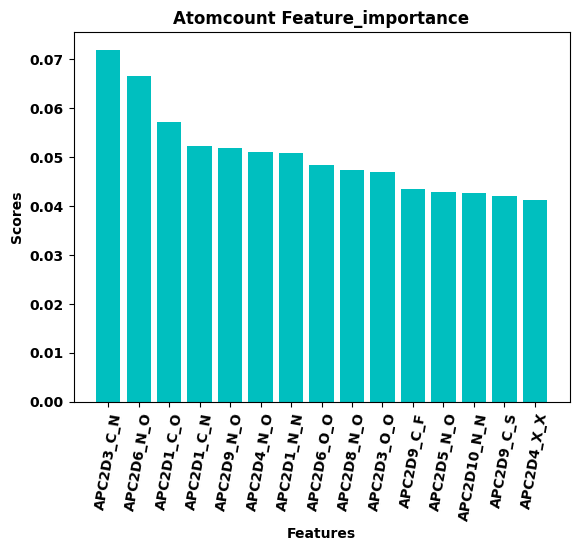

<Figure size 1000x1000 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
data = pd.read_csv('AtomPairCount2D.csv')
df = pd.DataFrame(data)
X = list(df.iloc[:, 1])
Y = list(df.iloc[:, 2])
plt.bar(X, Y, color='c')
plt.title("Atomcount Feature_importance", fontweight="bold")
plt.xlabel("Features", fontweight = 'bold')
plt.ylabel("Scores", fontweight = 'bold')
plt.xticks(rotation = 80, fontweight="bold")
plt.yticks(fontweight="bold")
fig = plt.figure(figsize=(10, 10))
plt.savefig("Features.jpg", bbox_inches = 'tight')

In [ ]:
Trainset = pd.concat([X_new,y_train],axis=1)
Trainset

,APC2D1_C_N,APC2D1_C_O,APC2D1_N_N,APC2D3_C_N,APC2D3_O_O,APC2D4_N_O,APC2D4_X_X,APC2D5_N_O,APC2D6_N_O,APC2D6_O_O,APC2D8_N_O,APC2D9_C_S,APC2D9_C_F,APC2D9_N_O,APC2D10_N_N,class
387,4,2,0,9,0,0,0,0,0,0,0,6,0,0,0,N
250,9,0,0,11,0,2,0,0,0,0,0,3,4,2,1,N
378,11,5,0,13,4,3,0,3,4,0,2,0,0,2,0,N
73,5,2,0,9,0,1,0,3,1,0,3,0,0,0,0,N
1185,7,6,0,9,0,3,0,1,2,2,0,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,3,3,0,2,0,1,0,0,1,0,0,0,0,0,0,N
1180,12,6,0,10,0,2,0,2,1,1,1,0,0,0,0,P
1147,6,3,0,9,0,0,0,0,2,0,2,2,0,0,0,N
527,8,3,1,10,0,4,0,2,2,0,2,2,0,2,0,P


In [ ]:
f = kBest.get_support(1)
Test_new = X_test[X_test.columns[f]]
Test_new

,APC2D1_C_N,APC2D1_C_O,APC2D1_N_N,APC2D3_C_N,APC2D3_O_O,APC2D4_N_O,APC2D4_X_X,APC2D5_N_O,APC2D6_N_O,APC2D6_O_O,APC2D8_N_O,APC2D9_C_S,APC2D9_C_F,APC2D9_N_O,APC2D10_N_N
693,3,6,2,6,4,5,0,4,4,1,1,0,0,0,0
834,8,2,1,20,0,0,0,0,1,0,2,0,0,0,0
1016,8,6,0,14,0,1,0,2,0,0,2,0,0,1,0
1113,0,11,0,0,2,0,0,0,0,0,0,0,0,0,0
31,5,1,0,11,0,1,0,1,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,14,0,0,17,0,2,1,0,4,0,0,1,0,0,2
909,17,5,0,20,0,4,0,2,3,1,4,0,0,1,2
270,7,0,0,11,0,2,0,0,0,0,0,3,4,2,0
349,13,10,0,11,0,1,0,4,4,1,5,5,0,5,0


In [ ]:
Testset = pd.concat([Test_new,y_test],axis=1)
Testset

,APC2D1_C_N,APC2D1_C_O,APC2D1_N_N,APC2D3_C_N,APC2D3_O_O,APC2D4_N_O,APC2D4_X_X,APC2D5_N_O,APC2D6_N_O,APC2D6_O_O,APC2D8_N_O,APC2D9_C_S,APC2D9_C_F,APC2D9_N_O,APC2D10_N_N,class
693,3,6,2,6,4,5,0,4,4,1,1,0,0,0,0,N
834,8,2,1,20,0,0,0,0,1,0,2,0,0,0,0,N
1016,8,6,0,14,0,1,0,2,0,0,2,0,0,1,0,P
1113,0,11,0,0,2,0,0,0,0,0,0,0,0,0,0,P
31,5,1,0,11,0,1,0,1,0,0,1,0,0,0,0,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,14,0,0,17,0,2,1,0,4,0,0,1,0,0,2,P
909,17,5,0,20,0,4,0,2,3,1,4,0,0,1,2,P
270,7,0,0,11,0,2,0,0,0,0,0,3,4,2,0,N
349,13,10,0,11,0,1,0,4,4,1,5,5,0,5,0,P


In [ ]:
Trainset.to_csv('Trainset_AtomPairCount2D_after_feature.csv')
Testset.to_csv('Testset_AtompairCount2D_after_feature.csv')

In [ ]:
Trainset['class'].replace('N', 0, inplace=True)
Trainset['class'].replace('P', 1, inplace=True)
Trainset.rename(columns = {"class": "class"}, inplace = True)
Trainset

<ipython-input-39-e976ed617192>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Trainset['class'].replace('N', 0, inplace=True)
<ipython-input-39-e976ed617192>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

,APC2D1_C_N,APC2D1_C_O,APC2D1_N_N,APC2D3_C_N,APC2D3_O_O,APC2D4_N_O,APC2D4_X_X,APC2D5_N_O,APC2D6_N_O,APC2D6_O_O,APC2D8_N_O,APC2D9_C_S,APC2D9_C_F,APC2D9_N_O,APC2D10_N_N,class
387,4,2,0,9,0,0,0,0,0,0,0,6,0,0,0,0
250,9,0,0,11,0,2,0,0,0,0,0,3,4,2,1,0
378,11,5,0,13,4,3,0,3,4,0,2,0,0,2,0,0
73,5,2,0,9,0,1,0,3,1,0,3,0,0,0,0,0
1185,7,6,0,9,0,3,0,1,2,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
733,3,3,0,2,0,1,0,0,1,0,0,0,0,0,0,0
1180,12,6,0,10,0,2,0,2,1,1,1,0,0,0,0,1
1147,6,3,0,9,0,0,0,0,2,0,2,2,0,0,0,0
527,8,3,1,10,0,4,0,2,2,0,2,2,0,2,0,1


In [ ]:
Testset['class'].replace('N', 0, inplace=True)
Testset['class'].replace('P', 1, inplace=True)
Testset.rename(columns = {"class": "class"}, inplace = True)
Testset.head()

<ipython-input-40-c538cf0d9b31>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  Testset['class'].replace('N', 0, inplace=True)
<ipython-input-40-c538cf0d9b31>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

,APC2D1_C_N,APC2D1_C_O,APC2D1_N_N,APC2D3_C_N,APC2D3_O_O,APC2D4_N_O,APC2D4_X_X,APC2D5_N_O,APC2D6_N_O,APC2D6_O_O,APC2D8_N_O,APC2D9_C_S,APC2D9_C_F,APC2D9_N_O,APC2D10_N_N,class
693,3,6,2,6,4,5,0,4,4,1,1,0,0,0,0,0
834,8,2,1,20,0,0,0,0,1,0,2,0,0,0,0,0
1016,8,6,0,14,0,1,0,2,0,0,2,0,0,1,0,1
1113,0,11,0,0,2,0,0,0,0,0,0,0,0,0,0,1
31,5,1,0,11,0,1,0,1,0,0,1,0,0,0,0,1


In [ ]:
Trainset.to_csv('Trainset1_AtomPairCount2D_after_feature.csv')
Testset.to_csv('Testset1_AtomPairCount2D_after_feature.csv')